In [1]:
import os
import copy
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.9.1+cu130


In [2]:
candidate_paths = [
    Path("./dataset/original"),
    Path("./dataset/standardized_256"),
    Path("./dataset/standardized_384"),
]


def is_dataset_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    if len(class_dirs) < 2:
        return False
    has_images = any(
        any(c.glob("*.jpg")) or any(c.glob("*.jpeg")) or any(c.glob("*.png"))
        for c in class_dirs
    )
    return has_images


data_dir = None
for p in candidate_paths:
    if is_dataset_root(p):
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError(
        "No valid dataset root found. Update candidate_paths manually."
    )

print("Using dataset path:", data_dir)

Using dataset path: dataset\original


Total images: 12259
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


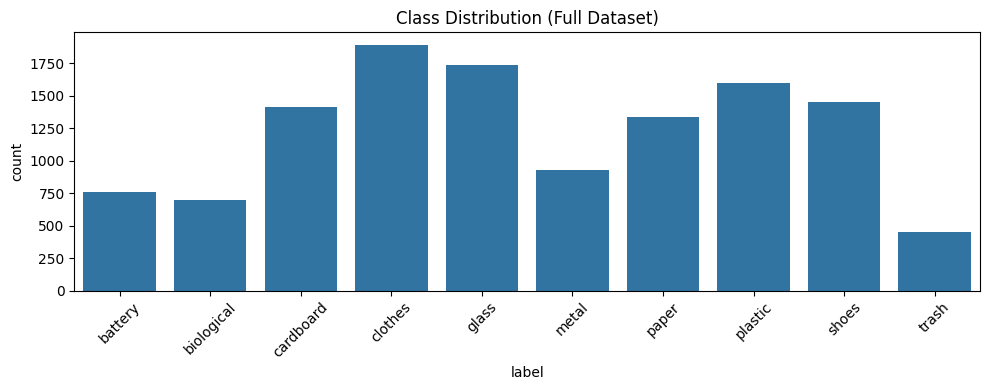

In [3]:
valid_ext = {".jpg", ".jpeg", ".png"}
records = []

class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

for cls in class_names:
    cls_dir = data_dir / cls
    for img_path in cls_dir.rglob("*"):
        if img_path.suffix.lower() in valid_ext:
            records.append(
                {
                    "filepath": str(img_path),
                    "label": cls,
                    "label_idx": class_to_idx[cls],
                }
            )

df = pd.DataFrame(records)
print("Total images:", len(df))
print("Classes:", class_names)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="label", order=class_names)
plt.xticks(rotation=45)
plt.title("Class Distribution (Full Dataset)")
plt.tight_layout()
plt.show()

In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_idx"],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_idx"],
    random_state=SEED,
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split["label"].value_counts().sort_index()
    print(f"\n{name} split class counts:")
    print(counts.to_string())

Train: 9807 | Val: 1226 | Test: 1226

Train split class counts:
label
battery        605
biological     559
cardboard     1129
clothes       1513
glass         1389
metal          744
paper         1069
plastic       1278
shoes         1159
trash          362

Val split class counts:
label
battery        75
biological     70
cardboard     141
clothes       190
glass         173
metal          93
paper         133
plastic       160
shoes         145
trash          46

Test split class counts:
label
battery        76
biological     70
cardboard     141
clothes       189
glass         174
metal          93
paper         134
plastic       159
shoes         145
trash          45


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

val_test_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class GarbageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label_idx"])
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = GarbageDataset(train_df, transform=train_tfms)
val_ds = GarbageDataset(val_df, transform=val_test_tfms)
test_ds = GarbageDataset(test_df, transform=val_test_tfms)

print("Datasets ready.")

Datasets ready.


In [6]:
train_labels = train_df["label_idx"].values
class_sample_count = np.array(
    [np.sum(train_labels == t) for t in range(len(class_names))]
)
class_weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,  # Now 0 for Windows safety
    pin_memory=True,
    drop_last=True,  # Ensure we don't get stuck if batch smaller than requested
    # Remove persistent_workers if present
    # persistent_workers=False,
    # timeout=0,
    # prefetch_factor=2,
    # worker_init_fn=None,
    collate_fn=None,
    multiprocessing_context=None,
    generator=None,
    worker_init_fn=None,
    timeout=0,
    # prefetch_factor=2,
    persistent_workers=False,
    pin_memory_device="",
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    # persistent_workers=False,
    # timeout=0,
    # prefetch_factor=2,
    # worker_init_fn=None,
    collate_fn=None,
    multiprocessing_context=None,
    generator=None,
    worker_init_fn=None,
    timeout=0,
    # prefetch_factor=2,
    persistent_workers=False,
    pin_memory_device="",
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    # persistent_workers=False,
    # timeout=0,
    # prefetch_factor=2,
    # worker_init_fn=None,
    collate_fn=None,
    multiprocessing_context=None,
    generator=None,
    worker_init_fn=None,
    timeout=0,
    # prefetch_factor=2,
    persistent_workers=False,
    pin_memory_device="",
)

print("Loaders ready:", len(train_loader), len(val_loader), len(test_loader))

Loaders ready: 306 38 38


In [7]:
# def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
#     mean = torch.tensor(mean).view(3, 1, 1)
#     std = torch.tensor(std).view(3, 1, 1)
#     return (img_tensor * std + mean).clamp(0, 1)


# images, labels = next(iter(train_loader))

# # Filter out any images with label -1 (failed to load)
# valid_indices = [i for i, lbl in enumerate(labels) if lbl != -1]
# images = images[valid_indices]
# labels = labels[valid_indices]

# n_show = min(10, len(images))
# fig, axes = plt.subplots(2, 5, figsize=(14, 6))
# for i, ax in enumerate(axes.flatten()):
#     if i < n_show:
#         img = denormalize(images[i].cpu())
#         ax.imshow(img.permute(1, 2, 0))
#         ax.set_title(class_names[labels[i].item()])
#     ax.axis("off")
# plt.suptitle("Sample Training Images")
# plt.tight_layout()
# plt.show()


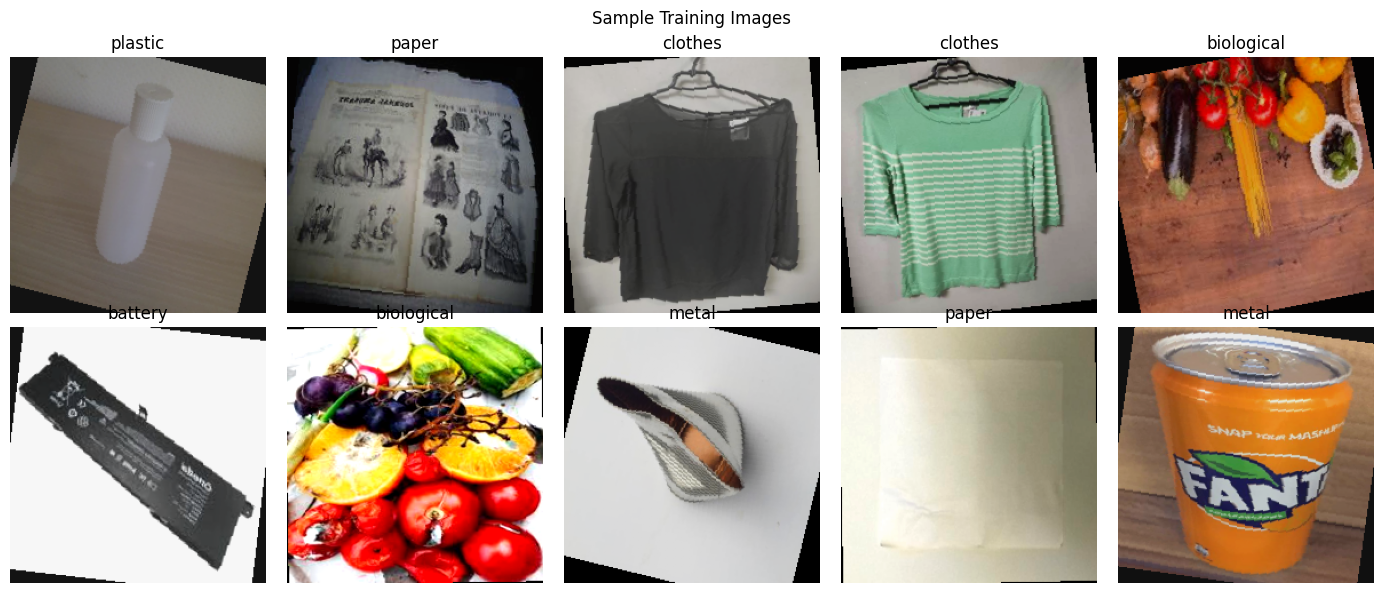

In [8]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i].cpu())
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

Default is now a stronger backbone for higher accuracy: `efficientnet_b3`.

Supported backbones:
- `resnet50`
- `efficientnet_b0`
- `efficientnet_b3` (recommended)
- `mobilenet_v3_large`

#  Build a Transfer Learning Model

In [9]:
def build_model(backbone: str, num_classes: int, freeze_features: bool = True):
    if backbone == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        feature_layers = [
            model.conv1,
            model.bn1,
            model.layer1,
            model.layer2,
            model.layer3,
            model.layer4,
        ]

    elif backbone == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        feature_layers = [model.features]

    elif backbone == "efficientnet_b3":
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        model = models.efficientnet_b3(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        feature_layers = [model.features]

    elif backbone == "mobilenet_v3_large":
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
        model = models.mobilenet_v3_large(weights=weights)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
        feature_layers = [model.features]

    else:
        raise ValueError("Unsupported backbone")

    if freeze_features:
        for module in feature_layers:
            for p in module.parameters():
                p.requires_grad = False

    return model


BACKBONE = "efficientnet_b3"
model = build_model(BACKBONE, num_classes=len(class_names), freeze_features=True).to(
    device
)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"Backbone: {BACKBONE}")
print(f"Trainable params: {trainable_params:,} / {all_params:,}")

Backbone: efficientnet_b3
Trainable params: 15,370 / 10,711,602


# Training Utilities

In [10]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, accs = [], []
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, targets))
    return float(np.mean(losses)), float(np.mean(accs))


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses, accs = [], []
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, targets))
    return float(np.mean(losses)), float(np.mean(accs))


def fit(
    model,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=2
    )

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    no_improve = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"lr {row['lr']:.2e} | "
            f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
            f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

# Train the Model (Stage 1)

In [11]:
EPOCHS = 10
LR = 1e-3

model, history_stage1 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=4,
)

history_stage1.tail()

Epoch 01/10 | lr 1.00e-03 | train_loss 0.9443 | train_acc 0.7595 | val_loss 0.5304 | val_acc 0.8586
Epoch 02/10 | lr 1.00e-03 | train_loss 0.5478 | train_acc 0.8356 | val_loss 0.4219 | val_acc 0.8840
Epoch 03/10 | lr 1.00e-03 | train_loss 0.4788 | train_acc 0.8531 | val_loss 0.4008 | val_acc 0.8873
Epoch 04/10 | lr 1.00e-03 | train_loss 0.4508 | train_acc 0.8580 | val_loss 0.3767 | val_acc 0.8857
Epoch 05/10 | lr 1.00e-03 | train_loss 0.4331 | train_acc 0.8596 | val_loss 0.3597 | val_acc 0.8906
Epoch 06/10 | lr 1.00e-03 | train_loss 0.4150 | train_acc 0.8676 | val_loss 0.3508 | val_acc 0.8890
Epoch 07/10 | lr 1.00e-03 | train_loss 0.4103 | train_acc 0.8655 | val_loss 0.3332 | val_acc 0.8956
Epoch 08/10 | lr 1.00e-03 | train_loss 0.3998 | train_acc 0.8689 | val_loss 0.3409 | val_acc 0.8947
Epoch 09/10 | lr 1.00e-03 | train_loss 0.3928 | train_acc 0.8694 | val_loss 0.3354 | val_acc 0.8914
Epoch 10/10 | lr 1.00e-03 | train_loss 0.4004 | train_acc 0.8708 | val_loss 0.3300 | val_acc 0.8898


,epoch,lr,train_loss,train_acc,val_loss,val_acc
5,6,0.001,0.415035,0.867647,0.350812,0.888980
6,7,0.001,0.410311,0.865502,0.333168,0.895559
7,8,0.001,0.399802,0.868873,0.340857,0.894737
8,9,0.001,0.392825,0.869383,0.335445,0.891447
9,10,0.001,0.400406,0.870813,0.329963,0.889803


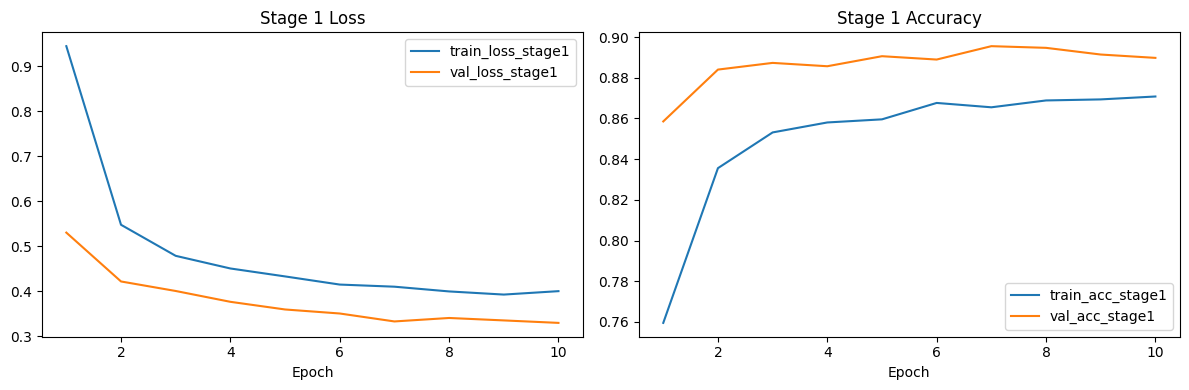

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_stage1["epoch"], history_stage1["train_loss"], label="train_loss_stage1"
)
axes[0].plot(
    history_stage1["epoch"], history_stage1["val_loss"], label="val_loss_stage1"
)
axes[0].set_title("Stage 1 Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    history_stage1["epoch"], history_stage1["train_acc"], label="train_acc_stage1"
)
axes[1].plot(history_stage1["epoch"], history_stage1["val_acc"], label="val_acc_stage1")
axes[1].set_title("Stage 1 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Fine-Tuning + Final Evaluation


We unfreeze the feature extractor and continue training with a smaller learning rate to improve final accuracy.

Epoch 01/6 | lr 1.00e-04 | train_loss 0.2568 | train_acc 0.9153 | val_loss 0.2156 | val_acc 0.9309
Epoch 02/6 | lr 1.00e-04 | train_loss 0.1485 | train_acc 0.9501 | val_loss 0.1710 | val_acc 0.9375
Epoch 03/6 | lr 1.00e-04 | train_loss 0.0950 | train_acc 0.9678 | val_loss 0.1841 | val_acc 0.9408
Epoch 04/6 | lr 1.00e-04 | train_loss 0.0667 | train_acc 0.9793 | val_loss 0.1402 | val_acc 0.9548
Epoch 05/6 | lr 1.00e-04 | train_loss 0.0514 | train_acc 0.9836 | val_loss 0.1565 | val_acc 0.9523
Epoch 06/6 | lr 1.00e-04 | train_loss 0.0426 | train_acc 0.9865 | val_loss 0.1623 | val_acc 0.9498


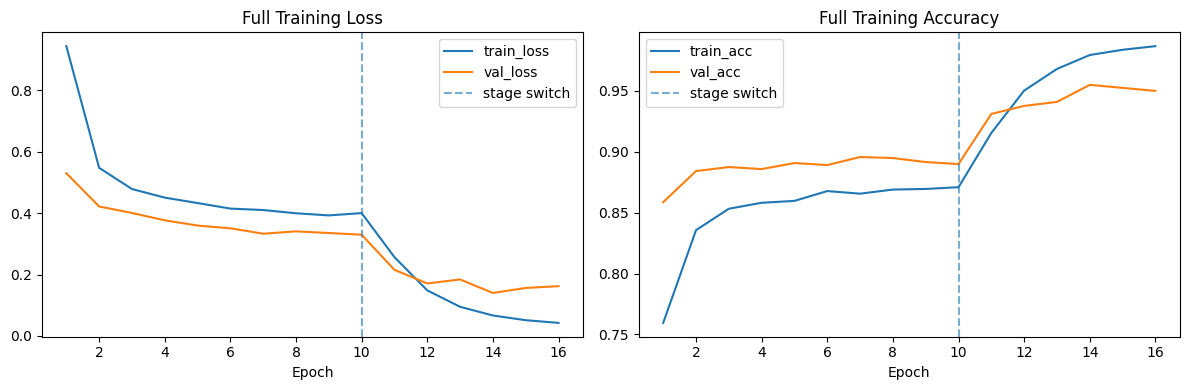

Test Accuracy: 0.9548

Classification Report:
              precision    recall  f1-score   support

     battery     0.9744    1.0000    0.9870        76
  biological     0.9577    0.9714    0.9645        70
   cardboard     0.9577    0.9784    0.9680       139
     clothes     0.9842    0.9947    0.9894       188
       glass     0.9310    0.9364    0.9337       173
       metal     0.8600    0.9247    0.8912        93
       paper     0.9606    0.9173    0.9385       133
     plastic     0.9536    0.9172    0.9351       157
       shoes     0.9930    0.9930    0.9930       143
       trash     0.9500    0.8636    0.9048        44

    accuracy                         0.9548      1216
   macro avg     0.9522    0.9497    0.9505      1216
weighted avg     0.9553    0.9548    0.9547      1216



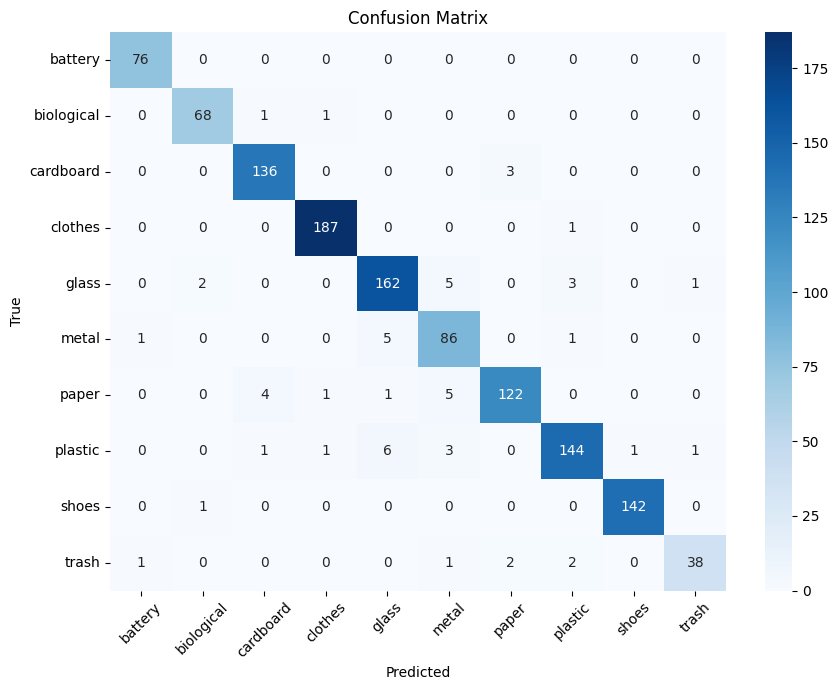

In [13]:
# Stage 2: unfreeze model for fine-tuning
for p in model.parameters():
    p.requires_grad = True

model, history_stage2 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=6,
    lr=1e-4,
    weight_decay=1e-5,
    patience=3,
)

# Merge history for visualization
history_stage1 = history_stage1.copy()
history_stage2 = history_stage2.copy()
if len(history_stage2) > 0:
    history_stage2["epoch"] = history_stage2["epoch"] + history_stage1["epoch"].max()
history_all = pd.concat([history_stage1, history_stage2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_all["epoch"], history_all["train_loss"], label="train_loss")
axes[0].plot(history_all["epoch"], history_all["val_loss"], label="val_loss")
axes[0].axvline(
    history_stage1["epoch"].max(), linestyle="--", alpha=0.6, label="stage switch"
)
axes[0].set_title("Full Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_all["epoch"], history_all["train_acc"], label="train_acc")
axes[1].plot(history_all["epoch"], history_all["val_acc"], label="val_acc")
axes[1].axvline(
    history_stage1["epoch"].max(), linestyle="--", alpha=0.6, label="stage switch"
)
axes[1].set_title("Full Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())
    return np.array(all_targets), np.array(all_preds)


y_true, y_pred = predict_loader(model, test_loader)

test_acc = (y_true == y_pred).mean()
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

overall_accuracy = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print("=== Overall Metrics ===")
print(f"Accuracy      : {overall_accuracy:.4f}")
print(f"Precision(Ma) : {prec_macro:.4f}")
print(f"Recall(Ma)    : {rec_macro:.4f}")
print(f"F1-Score(Ma)  : {f1_macro:.4f}")
print(f"Precision(Wt) : {prec_weighted:.4f}")
print(f"Recall(Wt)    : {rec_weighted:.4f}")
print(f"F1-Score(Wt)  : {f1_weighted:.4f}")

p, r, f1, s = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
)

metrics_df = pd.DataFrame(
    {
        "class": class_names,
        "precision": p,
        "recall": r,
        "f1_score": f1,
        "support": s,
    }
).sort_values("f1_score", ascending=False)

print("\n=== Per-Class Metrics (sorted by F1) ===")
display(
    metrics_df.style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
        }
    )
)

=== Overall Metrics ===
Accuracy      : 0.9548
Precision(Ma) : 0.9522
Recall(Ma)    : 0.9497
F1-Score(Ma)  : 0.9505
Precision(Wt) : 0.9553
Recall(Wt)    : 0.9548
F1-Score(Wt)  : 0.9547

=== Per-Class Metrics (sorted by F1) ===


,class,precision,recall,f1_score,support
8,shoes,0.9930,0.9930,0.9930,143
3,clothes,0.9842,0.9947,0.9894,188
0,battery,0.9744,1.0000,0.9870,76
2,cardboard,0.9577,0.9784,0.9680,139
1,biological,0.9577,0.9714,0.9645,70
6,paper,0.9606,0.9173,0.9385,133
7,plastic,0.9536,0.9172,0.9351,157
4,glass,0.9310,0.9364,0.9337,173
9,trash,0.9500,0.8636,0.9048,44
5,metal,0.8600,0.9247,0.8912,93


In [15]:
# Auto-highlight weaker classes and suggest targeted improvements

threshold_f1 = 0.93
fallback_top_n = 3

low_f1_df = metrics_df.sort_values("f1_score", ascending=True).copy()
flagged_df = low_f1_df[low_f1_df["f1_score"] < threshold_f1].copy()

if flagged_df.empty:
    flagged_df = low_f1_df.head(fallback_top_n).copy()

suggestion_map = {
    "trash": "Increase samples + hard augmentations (random crop, blur, brightness/contrast).",
    "plastic": "Add look-alike negatives (glass/metal) and use stronger color/texture augmentation.",
    "metal": "Add edge/reflective examples and train with higher-resolution images (256/300).",
    "paper": "Add crumpled/wet variants and background diversity.",
    "glass": "Include transparent/reflective cases with varied lighting.",
    "battery": "Add close-up and distance variants; balance orientation examples.",
    "cardboard": "Add folded/torn variants and cluttered backgrounds.",
    "shoes": "Use occlusion augmentation and mixed-background samples.",
    "biological": "Include decomposition/shape diversity and lighting changes.",
    "clothes": "Add texture and color diversity with background clutter.",
}

flagged_df["gap_to_0.95"] = (0.95 - flagged_df["f1_score"]).clip(lower=0)
flagged_df["recommended_action"] = (
    flagged_df["class"]
    .map(suggestion_map)
    .fillna(
        "Use class-focused augmentation + collect more hard samples for this class."
    )
)

print(f"=== Low-F1 Class Diagnostic (threshold: {threshold_f1:.2f}) ===")
print(f"Flagged classes: {len(flagged_df)}")

display(
    flagged_df[
        [
            "class",
            "precision",
            "recall",
            "f1_score",
            "support",
            "gap_to_0.95",
            "recommended_action",
        ]
    ].style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
            "gap_to_0.95": "{:.4f}",
        }
    )
)

print("\nQuick priority order (most urgent first):")
for _, row in flagged_df.sort_values("f1_score").iterrows():
    print(
        f"- {row['class']}: F1={row['f1_score']:.4f}, Action: {row['recommended_action']}"
    )

=== Low-F1 Class Diagnostic (threshold: 0.93) ===
Flagged classes: 2


,class,precision,recall,f1_score,support,gap_to_0.95,recommended_action
5,metal,0.8600,0.9247,0.8912,93,0.0588,Add edge/reflective examples and train with higher-resolution images (256/300).
9,trash,0.9500,0.8636,0.9048,44,0.0452,"Increase samples + hard augmentations (random crop, blur, brightness/contrast)."



Quick priority order (most urgent first):
- metal: F1=0.8912, Action: Add edge/reflective examples and train with higher-resolution images (256/300).
- trash: F1=0.9048, Action: Increase samples + hard augmentations (random crop, blur, brightness/contrast).


# Single-Image Inference Utility



In [16]:
@torch.no_grad()
def predict_image(image_path, model, transform, class_names):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    return class_names[pred_idx], float(probs[pred_idx]), probs


# Example usage (uncomment and edit path):
# sample_path = test_df.iloc[0]['filepath']
# pred_class, confidence, probs = predict_image(sample_path, model, val_test_tfms, class_names)
# print(f'Predicted: {pred_class} | Confidence: {confidence:.4f}')


This section saves everything needed for frontend integration:
- PyTorch weights (`.pt`)
- TorchScript model (`.pt`) for simple backend serving
- ONNX model (optional)
- `class_names.json` and `frontend_config.json`
- sample request payload file

In [18]:
artifacts_dir = Path('./artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'garbage_classifier_best.pt'
script_path = artifacts_dir / 'garbage_classifier_scripted.pt'
meta_path = artifacts_dir / 'metadata.json'
class_names_path = artifacts_dir / 'class_names.json'
frontend_config_path = artifacts_dir / 'frontend_config.json'
sample_request_path = artifacts_dir / 'sample_request.json'
onnx_path = artifacts_dir / 'garbage_classifier.onnx'

torch.save({
    'model_state_dict': model.state_dict(),
    'backbone': BACKBONE,
    'class_names': class_names,
    'img_size': IMG_SIZE,
    'mean': IMAGENET_MEAN,
    'std': IMAGENET_STD,
}, model_path)

with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump({
        'backbone': BACKBONE,
        'class_names': class_names,
        'img_size': IMG_SIZE,
        'mean': IMAGENET_MEAN,
        'std': IMAGENET_STD,
        'test_accuracy': float(test_acc),
    }, f, indent=2)

with open(class_names_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)

with open(frontend_config_path, 'w', encoding='utf-8') as f:
    json.dump({
        'input_type': 'image_file',
        'accepted_extensions': ['jpg', 'jpeg', 'png'],
        'output': {
            'predicted_class': 'string',
            'confidence': 'float',
            'top_k': [
                {'class_name': 'string', 'probability': 'float'}
            ]
        },
        'normalization': {
            'mean': IMAGENET_MEAN,
            'std': IMAGENET_STD,
            'resize': [IMG_SIZE, IMG_SIZE]
        }
    }, f, indent=2)

with open(sample_request_path, 'w', encoding='utf-8') as f:
    json.dump({
        'filename': 'example.jpg',
        'top_k': 3
    }, f, indent=2)

# TorchScript export for backend deployment
try:
    model.eval()
    scripted = torch.jit.script(model.cpu())
    scripted.save(str(script_path))
    model.to(device)
    print('TorchScript exported:', script_path)
except Exception as e:
    print('TorchScript export skipped:', e)
    model.to(device)

# Optional ONNX export
try:
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    model.eval()
    torch.onnx.export(
        model,
        dummy,
        onnx_path,
        input_names=['input'],
        output_names=['logits'],
        dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
        opset_version=17,
    )
    print('ONNX exported:', onnx_path)
except Exception as e:
    print('ONNX export skipped:', e)

print('Saved model:', model_path)
print('Saved metadata:', meta_path)
print('Saved frontend files:', class_names_path, frontend_config_path, sample_request_path)

TorchScript exported: artifacts\garbage_classifier_scripted.pt
ONNX export skipped: No module named 'onnxscript'
Saved model: artifacts\garbage_classifier_best.pt
Saved metadata: artifacts\metadata.json
Saved frontend files: artifacts\class_names.json artifacts\frontend_config.json artifacts\sample_request.json


# performed inference on custom openlandfill images

Backbone  : efficientnet_b3
Classes   : ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Device    : cuda

✅ Weights loaded from: artifacts\garbage_classifier_best.pt
Found 1327 images in ./dataset/garbage_dump
           filename  predicted  confidence
   image_000002.jpg      paper   47.830002
   image_000003.jpg biological   62.470001
   image_000004.jpg      glass   40.000000
   image_000005.jpg      metal   50.939999
   image_000006.jpg      trash   29.660000
   image_000007.jpg biological   34.299999
   image_000008.jpg      metal   64.900002
   image_000009.jpg      trash   38.740002
   image_000010.jpg      trash   97.620003
   image_000011.jpg      trash   74.110001
   image_000012.jpg      trash   30.389999
   image_000013.jpg      paper   62.790001
   image_000014.jpg      glass   32.770000
   image_000015.jpg      paper   62.750000
   image_000016.jpg      trash   90.410004
   image_000017.jpg      paper   68.430000
 

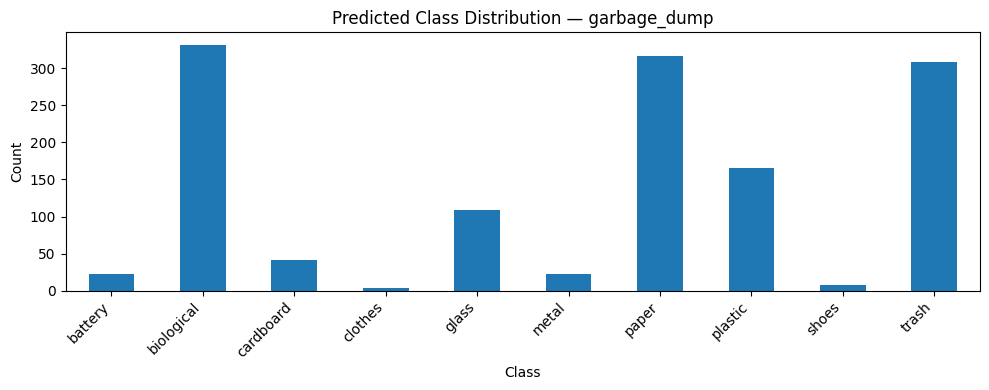


💾 Saved predictions to artifacts/garbage_dump_predictions.csv


In [1]:
# ─────────────────────────────────────────────────────────────
# SELF-CONTAINED EVALUATION  —  no prior cells needed
# ─────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

# ── 1. Config ───────────────────────────────────────────────
ARTIFACTS_DIR = Path("./artifacts")
TEST_DIR = "./dataset/garbage_dump"  # subfolders = class names
BATCH_SIZE_EVAL = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 2. Load metadata saved during training ──────────────────
with open(ARTIFACTS_DIR / "metadata.json") as f:
    meta = json.load(f)

BACKBONE = meta["backbone"]  # "efficientnet_b3"
class_names = meta["class_names"]  # ['battery', 'biological', ...]
IMG_SIZE = meta["img_size"]  # 224
IMAGENET_MEAN = meta["mean"]
IMAGENET_STD = meta["std"]
num_classes = len(class_names)

print(f"Backbone  : {BACKBONE}")
print(f"Classes   : {class_names}")
print(f"Device    : {device}")


# ── 3. Rebuild model architecture ───────────────────────────
def build_model(backbone, num_classes):
    if backbone == "efficientnet_b3":
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        model = models.efficientnet_b3(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif backbone == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif backbone == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif backbone == "mobilenet_v3_large":
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
        model = models.mobilenet_v3_large(weights=weights)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    else:
        raise ValueError(f"Unknown backbone: {backbone}")
    return model


# ── 4. Load weights ──────────────────────────────────────────
checkpoint = torch.load(
    ARTIFACTS_DIR / "garbage_classifier_best.pt", map_location=device
)
eval_model = build_model(BACKBONE, num_classes)
eval_model.load_state_dict(checkpoint["model_state_dict"])
eval_model = eval_model.to(device)
eval_model.eval()
print("\n✅ Weights loaded from:", ARTIFACTS_DIR / "garbage_classifier_best.pt")

## ── 5. Custom Dataset for flat folder (no class subfolders) ──
from torch.utils.data import Dataset
from PIL import Image


class FlatImageDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = Path(folder)
        self.transform = transform
        self.img_paths = sorted(
            [
                p
                for p in self.folder.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
            ]
        )
        print(f"Found {len(self.img_paths)} images in {folder}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.img_paths[idx].name  # returns (tensor, filename)


tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

custom_ds = FlatImageDataset("./dataset/garbage_dump", transform=tfms)
custom_loader = DataLoader(
    custom_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, num_workers=0
)

# ── 6. Inference (no ground truth — just predictions) ────────
all_preds, all_probs, all_filenames = [], [], []

with torch.no_grad():
    for images, filenames in custom_loader:
        logits = eval_model(images.to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_filenames.extend(filenames)

# ── 7. Results table ─────────────────────────────────────────
results_df = pd.DataFrame(
    {
        "filename": all_filenames,
        "predicted": [class_names[i] for i in all_preds],
        "confidence": [round(max(p) * 100, 2) for p in all_probs],
    }
)

print(results_df.to_string(index=False))

# ── 8. Prediction distribution ───────────────────────────────
plt.figure(figsize=(10, 4))
results_df["predicted"].value_counts().reindex(class_names, fill_value=0).plot(
    kind="bar"
)
plt.title("Predicted Class Distribution — garbage_dump")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 9. Optional: save predictions to CSV ─────────────────────
results_df.to_csv("./artifacts/garbage_dump_predictions.csv", index=False)
print("\n💾 Saved predictions to artifacts/garbage_dump_predictions.csv")